# Prove

Integrated spectral flux for a BlackBody:

\begin{equation}
BB(\lambda, T_{eff}) = \dfrac{2hc^2}{\lambda^5} \dfrac{1}{e^{{h c}/(\lambda k_b T_{eff})} - 1} \qquad [\text{J}\,s^{-1}\text{sr}^{-1}m^{-3}]
\end{equation}
Given $t_{eff}=\mathcal{T}\,;\,\lambda=\Lambda$, The energy per second is: $\rightarrow$
$$ BB(\Lambda,\mathcal{T})\cdot A_{eff} \cdot \Omega \equiv E_{BB} \qquad [\text{J}s^{-1}m^{-1}] $$
where:
- $\Omega$ is the total solid angle $\bigg(\dfrac{A_{eff}}{R^2}\bigg)$ $\rightarrow$ $2\pi\big(1-\cos{\frac{\alpha}{2}}\big)$ for a cone (α = parallax ?)
- $A_{eff}$ is the total collecting area

The photon energy is:

$$ E_\gamma = \dfrac{hc}{\lambda} $$

so that, the photon number emitted per unit time and unit area, from one hemisphere's surface ($\pi$) is:

$$ P_\lambda(T_{eff}) = \dfrac{\pi BB(\lambda,T_{eff})}{E_\gamma} = \dfrac{2\pi c}{\lambda^4}\dfrac{1}{e^{{h c}/(\lambda k_b T_{eff})} - 1}  \quad [\text{photons}\,s^{-1}cm^{-2}nm^{-1}]$$

To obtain the **spectral density flux** over a specific band, one must integrate:

$$ P(T_{eff}) = \int_{\lambda_1}^{\lambda_2} P_\lambda(T_{eff}) \, d\lambda $$

In [2]:
from astropy import units as u
from astropy.constants import h, c, k_B
from astropy.modeling.models import BlackBody
from astropy.visualization import quantity_support
import numpy as np
from astropy.table import QTable

Gbp = QTable.read("data/gaiaDR3passband.fits")

In [3]:
T_eff = 5778 * u.K
A = 1*(u.erg/(u.cm**2 * u.s * u.AA * u.sr))
bb = BlackBody(temperature=T_eff, scale=A)

In [4]:
wl = 5000 * u.AA
val = bb(wl)

print(f"Black body flux at 5000 A: {val:.2e} (cgs)  ;  {val.to(u.J / (u.m**3 * u.sr * u.s)):.2e} (SI)")

Black body flux at 5000 A: 2.64e+06 erg / (Angstrom s sr cm2) (cgs)  ;  2.64e+13 J / (s sr m3) (SI)


In [5]:
val_SI = val.to(u.J / (u.m**3 * u.sr * u.s))

lambd = wl.to(u.m)
A_eff = 1.45*0.5 * u.m**2

D = (1*u.kpc).to(u.m) # distance

Om = 4*np.pi # (A_eff / D**2) * u.sr 

E_gamma = h*c/lambd

P_BB = val_SI * A_eff * Om / E_gamma

In [6]:
P_BB*lambd*4.42 * u.s

<Quantity 1.33670913e+27 1 / sr>

Photon flux at λ = 500.0 nm: 2.086e+26 1 / (s cm3)


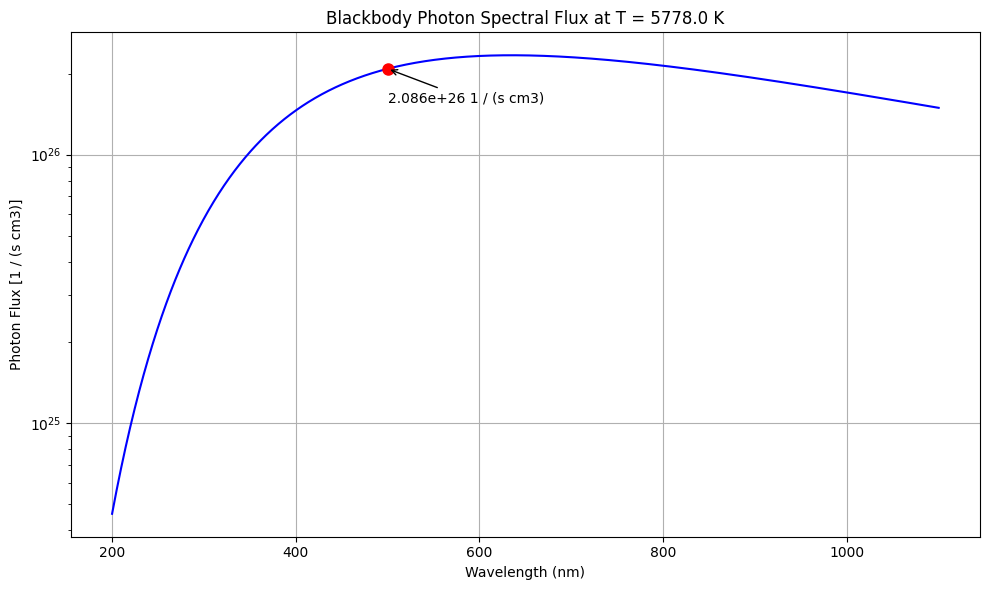

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

def blackbody_photon_flux(wavelength_nm, T_eff):
    """
    Calculate the blackbody photon spectral flux at the stellar surface.
    
    Parameters:
    -----------
    wavelength_nm : float or ndarray
        Wavelength in nanometers
    T_eff : float
        Effective temperature of the star in Kelvin
    
    Returns:
    --------
    flux : float or ndarray
        Photon spectral flux in photons s⁻¹ cm⁻² nm⁻¹
    """
    # Convert wavelength to meters for SI calculation
    wavelength_cm = wavelength_nm.to('cm')  # Convert to meters
    
    c_cm = c.to('cm/s')  # Speed of light in cm/s
    k = k_B      # Boltzmann constant (J/K)
    
    # Calculate the exponent term
    if not isinstance(T_eff, u.Quantity):
        T_eff = T_eff * u.K
    exponent = h*c_cm/(wavelength_cm*k*T_eff)
    
    # Avoid overflow in the exponential
    with np.errstate(over='ignore'):
        # Use expm1 for numerical stability when exponent is small
        denominator = np.expm1(exponent)
    
    # Calculate photon number flux (per m² per m wavelength)
    # This is 2πc/λ⁴ × 1/(e^(hc/λkT)-1)
    photon_flux = (2.0 * np.pi * c_cm) / (wavelength_cm**4) / denominator
    
    return photon_flux

# Example: Calculate and plot photon flux for a Sun-like star (T_eff = 5778 K)

# Set up wavelength array from UV to near-IR (200-1000 nm)
wavelengths = np.linspace(200, 1100, 1100) * u.nm

# Calculate photon flux
solar_T_eff = 5778 *u.K
flux = blackbody_photon_flux(wavelengths, solar_T_eff)

# Plot the result
with quantity_support():
    plt.figure(figsize=(10, 6))
    plt.plot(wavelengths, flux, 'b-')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel(f'Photon Flux [{flux.unit}]')
    plt.title(f'Blackbody Photon Spectral Flux at T = {solar_T_eff}')
    plt.grid(True)

    # Calculate flux at a specific wavelength (e.g., 500 nm)
    specific_wavelength = 500 * u.nm
    specific_flux = blackbody_photon_flux(specific_wavelength, solar_T_eff)
    print(f"Photon flux at λ = {specific_wavelength}: {specific_flux:.3e}")

    # Mark this point on the plot
    plt.plot(specific_wavelength, specific_flux, 'ro', ms=8)
    plt.annotate(f'{specific_flux:.3e}', 
                xy=(specific_wavelength, specific_flux),
                xytext=(specific_wavelength, specific_flux*0.75),
                arrowprops=dict(arrowstyle='->'))

    plt.yscale('log')
    plt.tight_layout()
    plt.show()

To commpute the con version factor from an observed flux and a black body emitted one is

$$ C = F_G\cdot\bigg[\dfrac{\int BB(\lambda,T_{eff}\,S(\lambda)\,\lambda\, d\lambda)}{\int S(\lambda)\,\lambda\, d\lambda}\bigg]^{-1} $$

then, for our total throughput, we can use the **trapezoidal integral** rule:

$$ SS = \int S(\lambda)\,\lambda\, d\lambda \simeq \frac{1}{2}\sum_i  \big[(S_i·λ_i)+(S_{i+1}·λ_{i+1})\big]·\Delta\lambda$$

while as for the black body integration:

$$ BI(T_{eff}) \simeq \frac{1}{2}\sum_i  \big[(BB_i\cdot S_i·λ_i)+(BB_{i+1}\cdot S_{i+1}·λ_{i+1})\big]·\Delta\lambda $$

So, in the end, given an **Effective Temperature $T_{eff}$** associated to a star with magnitude in the Gaia G-band $M_G$, the conversion factor is:

$$ C = F_G\cdot\dfrac{BI(T_{eff})}{SS} = Z_G\, 10^{-0.4M_G} \cdot\dfrac{BI(T_{eff})}{SS} $$

Obtaining $C(T_{eff})$ and fitting the curve, canbe used to obtain a semi-analythical simple formula to use to compute C

# Spectra with `SYNPHOT`

In [1]:
import synphot as sp
import bincatsim as bs
from astropy.table import QTable
from astropy import units as u
from matplotlib import pyplot as plt
import bincatsim as bs

ccd = bs.CCD(bs.paths.PSF_FILE)


Gpb = QTable.read(bs.paths.PASSBAND_FILE).filled(0)
S = Gpb['G']
G_zero_point_jy = ccd._bands['zero_point']


[XuPy] Device 0 available - GPU : `NVIDIA GeForce RTX 5080 Laptop GPU`
       Memory = 16220.22 MB | Compute Capability = 12.0
       Using CuPy 13.6.0 for acceleration.


/home/pietrof/miniforge3/envs/bincat/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


The `stellar flux` is expressed in units of

> $$\mathrm{PHOTLAM} = \dfrac{\gamma}{s\,cm^2\,\AA}

The Spectrum is modelled as a normalized 1D Black Body (plank function):

\begin{cases}
    B(\lambda, T_{eff}) = \dfrac{BB(\lambda, T_{eff})}{\Omega} \quad ; \\
    \\ \notag
\text{with :} \qquad \begin{align} \notag
    BB(\lambda, T_{eff}) &= \dfrac{2hc^2}{\lambda^5} \dfrac{1}{e^{{h c}/(\lambda k_b T_{eff})} - 1}  \\ \notag \\ \notag
    \Omega & = \pi\dfrac{R_{\odot}^2}{d^2} \quad \rightarrow \quad d=1\,kpc\\ \notag
    \end{align}
\end{cases}

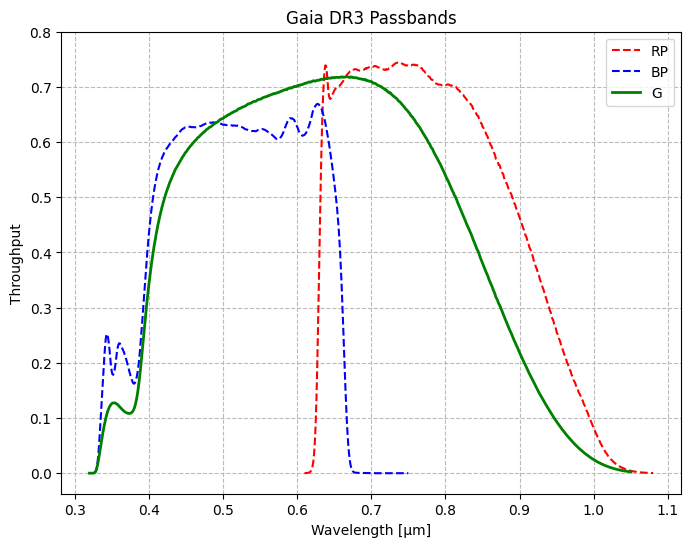

In [2]:
ccd.display_passbands()

1. Compute the current band-averaged flux density of the blackbody
    You start with a spectrum $f_\nu^{bb}(\nu)$ and a filter transmission $T(\nu)$ (your g band).
    The synthetic observation returns an effective flux density in Jy, conceptually:

    > $$\langle f_\nu^{bb} \rangle_g \;\approx\; \frac{\int f_\nu^{bb}(\nu)\,W_g(\nu)\,d\nu}{\int W_g(\nu)\,d\nu} $$

    where $W_g$ is the band weighting used by synphot for that mode (throughput and detector convention).

    So fnu_bb is “what this blackbody looks like in the g band, as a single representative $f_\nu$ value.”

2. Build a multiplicative scale factor to force zero-point flux
    You define

    > $$ s = \frac{f_{\nu,0}}{\langle f_\nu^{bb} \rangle_g} $$

    where $f_{\nu,0}$ is G_zero_point_jy.
    Then you scale the whole spectrum:

    > $$     f_\nu^{star}(\nu) = s\,f_\nu^{bb}(\nu)     $$

    Because the operation is linear, the new band-averaged flux becomes:

    > $$ \langle f_\nu^{star} \rangle_g = s\,\langle f_\nu^{bb} \rangle_g = f_{\nu,0} $$

3. Verify with a second synthetic observation.
    You re-observe the scaled spectrum and get fnu_g0, which should be numerically very close to $f_{\nu,0}$.

4. Convert to magnitude
        You apply the standard magnitude definition:

    > $$ G = -2.5\log_{10}\!\left(\frac{\langle f_\nu^{star}\rangle_g}{f_{\nu,0}}\right) $$

    If calibration is exact, ratio $=1$, so $G=0$ mag.

So in plain words: you take an arbitrary blackbody shape, rescale its amplitude so that its synthetic g-band flux equals the adopted zero-point, and therefore define a 0-mag reference spectrum in that band. Any tiny nonzero result comes from numerical binning, tapering, and integration discretization.

In [3]:
# 1) Wavelength grid (already in your notebook, unit = nm)
wave = Gpb["lambda"].to(u.AA)

# 2) Stellar SED model: blackbody at 5800 K (Sun-like)
bb = sp.SourceSpectrum(sp.models.BlackBodyNorm1D, temperature=5800 * u.K)

# Build a custom Gaia-G spectral element from your tabulated passband
g_band = sp.SpectralElement(
    sp.models.Empirical1D,
    points=wave,
    lookup_table=np.asarray(Gpb["G"], dtype=float)
)

fnu_bb = sp.Observation(bb, g_band, binset=wave, force="taper").effstim(u.Jy)

scale_g0 = (G_zero_point_jy / fnu_bb).decompose().value[0]
star_spec = bb * scale_g0

# Check: should be ~0 mag by construction
obs_g0 = sp.Observation(star_spec, g_band, binset=wave, force="taper")
fnu_g0 = obs_g0.effstim(u.Jy)
Gmag = -2.5 * np.log10((fnu_g0 / G_zero_point_jy).value)

print(f"Initial <Fν>_G : {fnu_bb:.6g}")
print(f"Scale factor   : {scale_g0:.6e}")
print(f"Final <Fν>_G   : {fnu_g0:.6g}")
print(f"Recovered Gmag : {Gmag[0]:.3e} mag")

Initial <Fν>_G : 0.00438834 Jy
Scale factor   : 6.904668e+06
Final <Fν>_G   : 30300 Jy
Recovered Gmag : 1.205e-16 mag


The **magnitude relation** is right in spirit, but the flux conversion needs the **zeropoints** to be explicit.

For any band $X$,

$$
m_X = -2.5\log_{10}\!\left(\frac{F_X}{F_{0,X}}\right)
\quad\Longrightarrow\quad
F_X = F_{0,X}\,10^{-0.4\,m_X}
$$

So for Gaia $G$,

$$
F_G = F_{0,G}\,10^{-0.4\,G}
$$

and if you want to express it using $V$ and the color $G-V$,

$$
G = V + (G-V)
$$

therefore

$$
F_G = F_{0,G}\,10^{-0.4\,[V+(G-V)]}
$$

If you start from the **V-band flux** instead of the magnitude, then:

$$
F_G = F_V \,\frac{F_{0,G}}{F_{0,V}}\,10^{-0.4\,(G-V)}
$$